In [1]:
import pandas as pd

df = pd.read_csv("logistics_dataset.csv")
df.head()

,order_id,product,product_description,origin,destination,shipping_mode,order_date,delay_days,customer_review
0,ORDXAJI0Y6,Laptop,Laptop shipped via Air from Ibadan to Kano,Ibadan,Kano,Air,1/31/2024,3,delayed shipment due to weather
1,ORDHSAHXTH,Monitor,Monitor shipped via Road from Port Harcourt to...,Port Harcourt,Lagos,Road,12/15/2025,2,tracking updates were helpful
2,ORDMF8MDD4,Monitor,Monitor shipped via Express from Port Harcourt...,Port Harcourt,Lagos,Express,7/3/2025,4,delayed shipment due to weather
3,ORD9NT3W5U,Laptop,Laptop shipped via Sea from Lagos to Abuja,Lagos,Abuja,Sea,3/22/2024,6,excellent logistics experience
4,ORD5NQ4FMY,Laptop,Laptop shipped via Road from Ibadan to Abuja,Ibadan,Abuja,Road,6/16/2024,2,poor handling caused delay


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   order_id             1000 non-null   object
 1   product              1000 non-null   object
 2   product_description  1000 non-null   object
 3   origin               1000 non-null   object
 4   destination          1000 non-null   object
 5   shipping_mode        1000 non-null   object
 6   order_date           1000 non-null   object
 7   delay_days           1000 non-null   int64 
 8   customer_review      1000 non-null   object
dtypes: int64(1), object(8)
memory usage: 70.4+ KB


In [3]:
df.describe()

,delay_days
count,1000.000000
mean,2.620000
std,1.853385
min,0.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,10.000000


In [4]:
df.isnull().sum()

order_id               0
product                0
product_description    0
origin                 0
destination            0
shipping_mode          0
order_date             0
delay_days             0
customer_review        0
dtype: int64

In [5]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["delay_days"] = df["delay_days"].astype(int)

In [6]:
df["delay_days"].mean()

np.float64(2.62)

In [7]:
df["shipping_mode"].value_counts()

shipping_mode
Road       261
Express    261
Air        249
Sea        229
Name: count, dtype: int64

In [8]:
df.groupby(["origin", "destination"]).size().sort_values(ascending=False).head(10)

origin         destination  
Ibadan         Abuja            51
               Kano             49
               Ibadan           48
Kano           Lagos            46
Port Harcourt  Kano             45
Lagos          Abuja            45
Kano           Port Harcourt    45
               Kano             44
Port Harcourt  Lagos            43
Lagos          Kano             42
dtype: int64

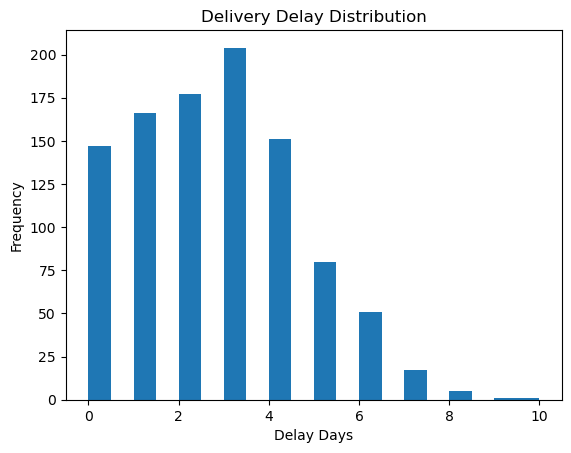

In [22]:
import matplotlib.pyplot as plt

plt.hist(df["delay_days"], bins=20)
plt.title("Delivery Delay Distribution")
plt.xlabel("Delay Days")
plt.ylabel("Frequency")
# plt.show()
plt.savefig("delay_distribution.png")

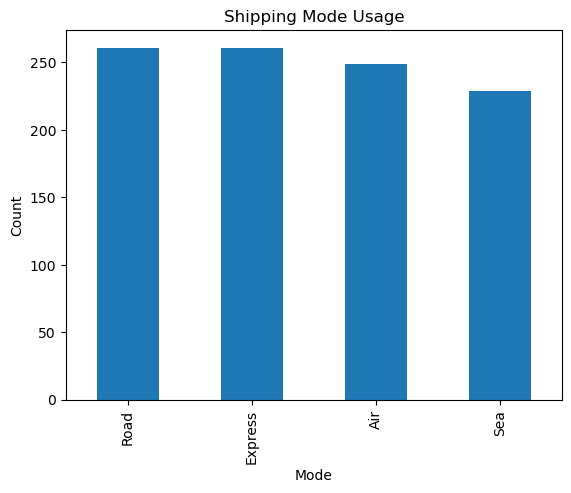

In [24]:
df["shipping_mode"].value_counts().plot(kind="bar")
plt.title("Shipping Mode Usage")
plt.xlabel("Mode")
plt.ylabel("Count")
# plt.show()
plt.savefig("shipping_modes.png")

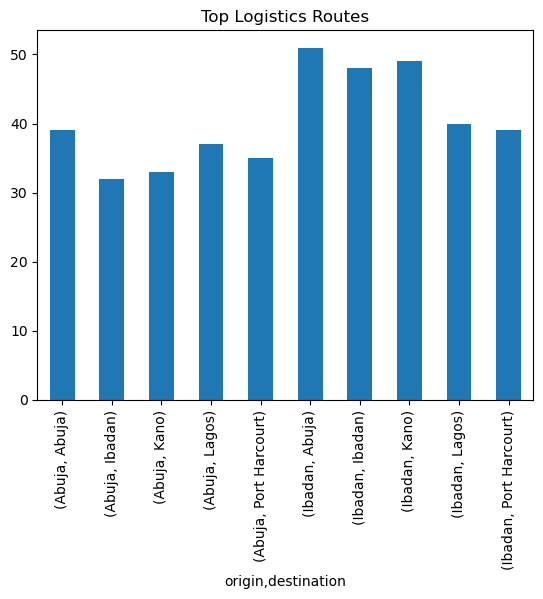

In [25]:
top_routes = df.groupby(["origin", "destination"]).size().head(10)
top_routes.plot(kind="bar")
plt.title("Top Logistics Routes")
# plt.show()
plt.savefig("logistics_routes.png")

In [13]:
import re

def extract_delay_reason(text):
    text = text.lower()
    if re.search("weather", text):
        return "Weather"
    elif re.search("traffic", text):
        return "Traffic"
    elif re.search("damage|handling", text):
        return "Handling Issue"
    elif re.search("delay", text):
        return "System Delay"
    else:
        return "Unknown"

df["delay_reason"] = df["product_description"].apply(extract_delay_reason)

df["delay_reason"].value_counts()

delay_reason
Unknown    1000
Name: count, dtype: int64

In [14]:
!pip install wordcloud

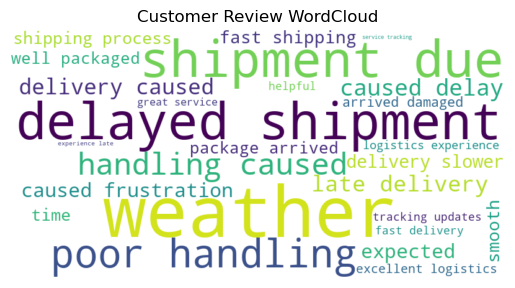

In [26]:
from wordcloud import WordCloud

text = " ".join(df["customer_review"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Customer Review WordCloud")
# plt.show()
plt.savefig("wordcloud.png")

## Key Insights

- Average delivery delay was calculated across all shipments
- Road transport was the most commonly used shipping mode
- Weather and handling issues were major causes of delay
- Customer feedback shows mixed satisfaction levels
- Lagos and Abuja routes recorded highest logistics volume

# Transport and Logistics Data Analysis Using Python